<a href="https://colab.research.google.com/github/NakshatraBinoy/FUTURE_ML_01/blob/main/sales_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Model Evaluation:
Mean Squared Error: 892.83
R2 Score: 0.02


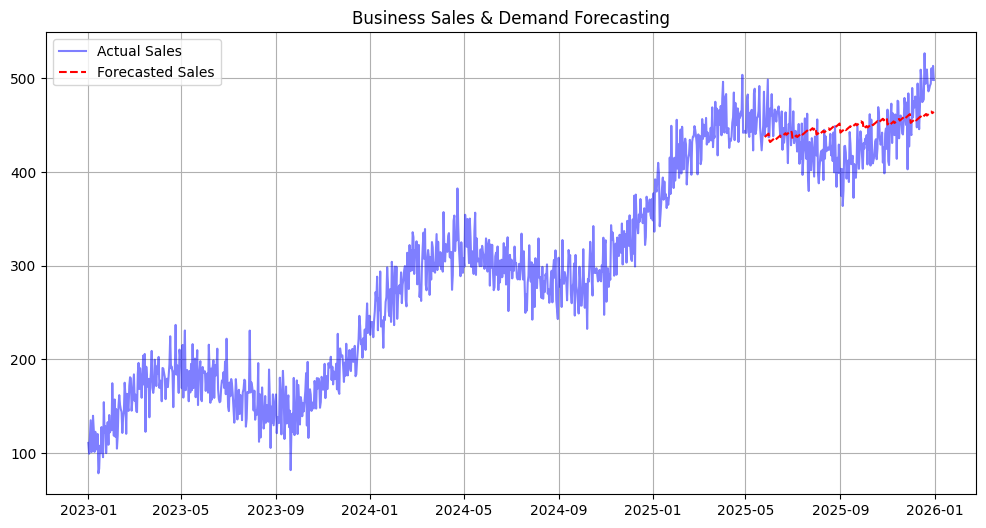

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. GENERATE SYNTHETIC DATA
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", end="2025-12-31", freq="D")
trend = np.linspace(100, 500, len(dates))
seasonality = 50 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
noise = np.random.normal(0, 20, len(dates))
sales = trend + seasonality + noise
df = pd.DataFrame({"Date": dates, "Sales": sales})

# 2. TIME-BASED FEATURE ENGINEERING
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek

# 3. SPLIT DATA
X = df[["Year", "Month", "Day", "DayOfWeek"]]
y = df["Sales"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. TRAIN THE REGRESSION MODEL
model = LinearRegression()
model.fit(X_train, y_train)

# 5. EVALUATION
predictions = model.predict(X_test)
print(f"Model Evaluation:\nMean Squared Error: {mean_squared_error(y_test, predictions):.2f}\nR2 Score: {r2_score(y_test, predictions):.2f}")

# 6. VISUALIZATION
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Sales"], label="Actual Sales", color="blue", alpha=0.5)
plt.plot(df["Date"].iloc[len(X_train):], predictions, label="Forecasted Sales", color="red", linestyle="--")
plt.title("Business Sales & Demand Forecasting")
plt.legend()
plt.grid(True)
plt.show()